In [5]:
# Import libraries
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import os
import seaborn as sns

## Lectura de los archivos

In [6]:
# Get files path
from pathlib import Path

folder_path = Path('images')

# Filter the directory contents to include files only
files = [f.name for f in folder_path.iterdir()]

files_corr = files

In [5]:
# Check files path
files_corr

['envisat_wsm_2007_03_26_hh_pot_cal_cg_gk5wgs84_nn_sub.tif',
 'envisat_wsm_2008_05_19_hh_pot_cal_cg_gk5wgs84_nn_sub.tif',
 'envisat_wsm_2005_09_12_hh_pot_cal_cg_gk5wgs84_nn_sub.tif',
 'envisat_wsm_2008_03_10_hh_pot_cal_cg_gk5wgs84_nn_sub.tif']

In [7]:
# Read vector samples
gdf_samples = gpd.read_file('Muestras/muestras_TP5_todas.shp')#.to_crs(epsg=9001)

# --
gdf_samples['Cobertura'] = gdf_samples['nombre'].str[:-1]

# Display vector samples
gdf_samples.sample(5)

,Id,nombre,geometry,Cobertura
9,10,pastizal1,"POLYGON ((5575671.617 6306784.165, 5574349.786...",pastizal
4,17,ciudad2,"POLYGON ((5638647.511 6167755.471, 5639744.964...",ciudad
1,37,laguna1,"POLYGON ((5490473.97 6383081.215, 5491281.32 6...",laguna
13,29,pradera1,"POLYGON ((5451153.595 6423096.012, 5452078.777...",pradera
5,19,ciudad1,"POLYGON ((5437870.761 6352638.169, 5438605.488...",ciudad


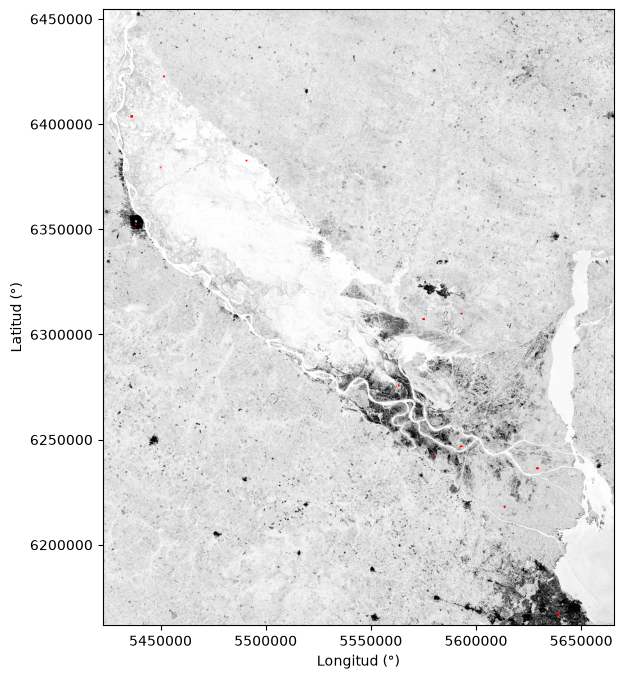

In [7]:
# Visualizo junto a los polígonos de muestreo

# Abro una de las imágenes
with rio.open(os.path.join('images', files_corr[0])) as src:
    img = src.read()
    extent = plotting_extent(src) 

# Reproyecto el archivo vectorial
gdf_samples = gdf_samples.to_crs(src.crs)

# Ploteamos la imagen con los vectores superpuestos
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img[0], extent = extent, 
          cmap ='Grays',
          vmin=np.nanpercentile(img[0], 1), vmax=np.nanpercentile(img[0], 99))
gdf_samples.plot(ax=ax, legend = True, color='red')
ax.ticklabel_format(style='plain')

# Etiquetas y título
ax.set_ylabel('Latitud (°)')
ax.set_xlabel('Longitud (°)')

plt.show()

## Extracción de los datos de backscatering a un diccionario

**Estructura:**
1) Fecha
2) Tipo de cobertura
3) Estadísticos: Mediana, desvío estándar, primer quantil, y tercer quantil (En dB)

In [8]:
# --
samp_unique = gdf_samples['nombre'].unique()

# --
samp_unique

<StringArray>
[  'laguna2',   'laguna1',   'juncal2',   'juncal1',   'ciudad2',   'ciudad1',
   'bosque2',   'bosque1', 'pastizal2', 'pastizal1',  'pajonal2',  'pajonal1',
  'pradera2',  'pradera1']
Length: 14, dtype: str

In [9]:
# --
dict_samp_seas = {}

# --
for p in files_corr:
#p = files_corr[0]

    with rio.open(os.path.join('images', p)) as src:
        #print('-'.join(p.split('_')[2:4]))
        dict_samp = {}
        # --

        # --

        for s in samp_unique:
            #print(s)
            sample_sel = gdf_samples[gdf_samples['nombre']==s]
            mask_data, mask_transform = mask(dataset=src, shapes=sample_sel.geometry, nodata=None, crop=True)
            # --
            x = mask_data
            x[0][x[0] == 0] = np.nan 
            x = x[~np.isnan(x)] # Remove nan values
            # --
            #print(x.flatten())
            dict_vals = {}
            dict_vals['values'] = x.flatten()
            dict_vals['median_dec'] = 10*np.log10(np.median(x))
            dict_vals['std_dec'] = 10*np.log10(np.std(x))
            dict_vals['25q_dec'] = 10*np.log10(np.quantile(x, 0.25))
            dict_vals['75q_dec'] = 10*np.log10(np.quantile(x, 0.75))
            
            # --
            dict_samp[s] = dict_vals
            
        # --
        dict_samp_seas[f'{'-'.join(p.split('_')[2:4])}'] = dict_samp
            


## Visualización de los resultados

In [11]:
samples_sel

<StringArray>
['laguna2', 'laguna1', 'juncal2', 'juncal1']
Length: 4, dtype: str

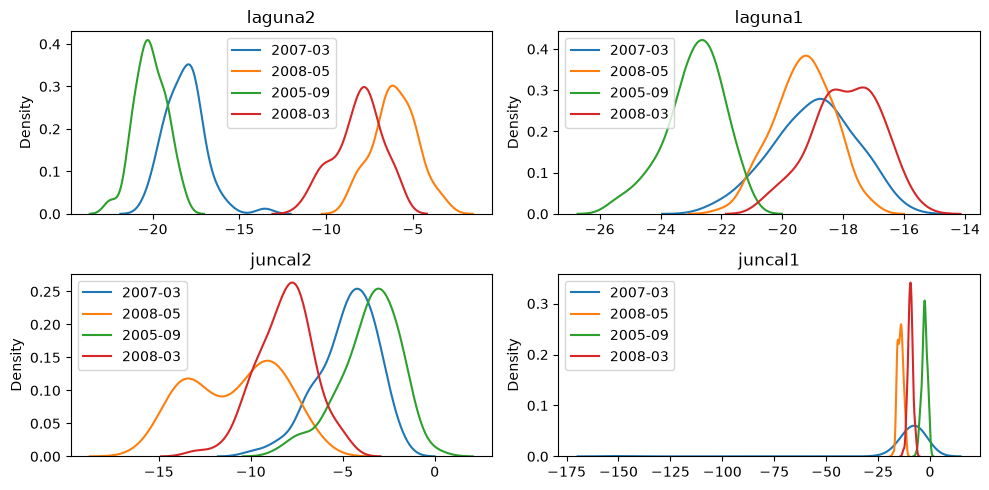

In [10]:
# --
fig, ax = plt.subplots(2, 2, figsize=(10, 5), tight_layout=True)
ax = ax.ravel()

# --
samples_sel = samp_unique[:4]

# --
for idx, s in enumerate(samples_sel):
    for d in dict_samp_seas.keys():
        values = dict_samp_seas[d][s]['values']
        #ax[idx].hist(values, bins=50, histtype='step', linewidth=1.5, alpha=0.7, label=d)
        sns.kdeplot(10*np.log10(values), ax=ax[idx], label=d)
        ax[idx].legend()
        ax[idx].set_title(f'{s}', fontsize=12)

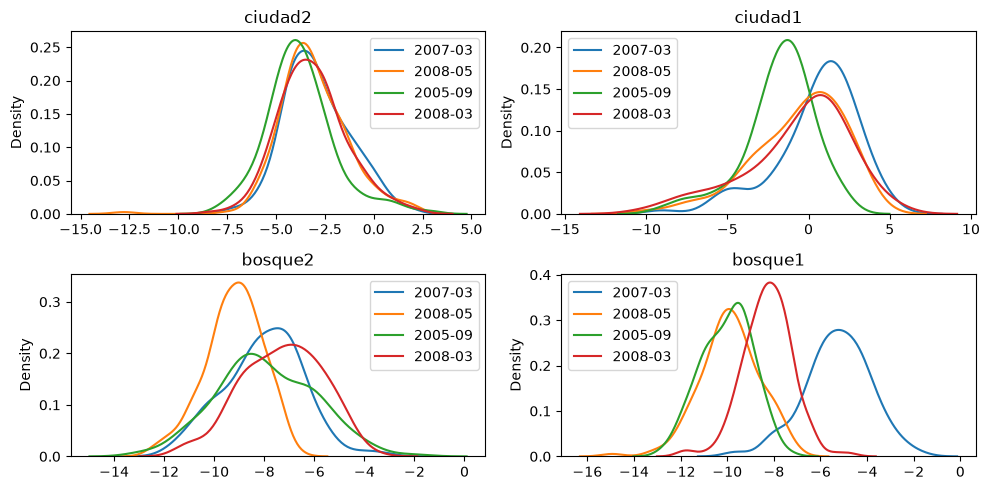

In [11]:
# --
fig, ax = plt.subplots(2, 2, figsize=(10, 5), tight_layout=True)
ax = ax.ravel()

# --
samples_sel = samp_unique[4:8]

# --
for idx, s in enumerate(samples_sel):
    for d in dict_samp_seas.keys():
        values = dict_samp_seas[d][s]['values']
        #ax[idx].hist(values, bins=50, histtype='step', linewidth=1.5, alpha=0.7, label=d)
        sns.kdeplot(10*np.log10(values), ax=ax[idx], label=d)
        ax[idx].legend()
        ax[idx].set_title(f'{s}', fontsize=12)

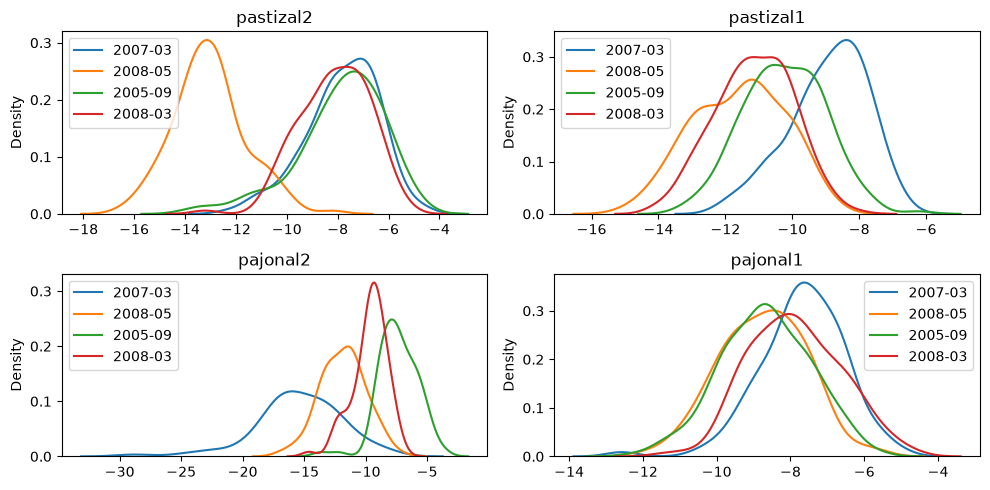

In [12]:
# --
fig, ax = plt.subplots(2, 2, figsize=(10, 5), tight_layout=True)
ax = ax.ravel()

# --
samples_sel = samp_unique[8:12]

# --
for idx, s in enumerate(samples_sel):
    for d in dict_samp_seas.keys():
        values = dict_samp_seas[d][s]['values']
        #ax[idx].hist(values, bins=50, histtype='step', linewidth=1.5, alpha=0.7, label=d)
        sns.kdeplot(10*np.log10(values), ax=ax[idx], label=d)
        ax[idx].legend()
        ax[idx].set_title(f'{s}', fontsize=12)

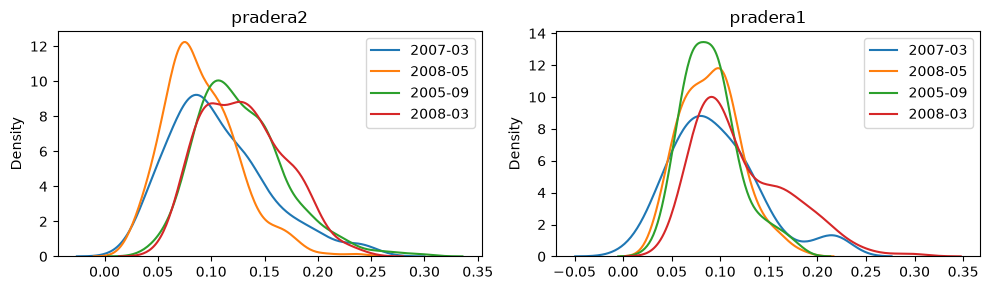

In [36]:
# --
fig, ax = plt.subplots(1, 2, figsize=(10, 3), tight_layout=True)
ax = ax.ravel()

# --
samples_sel = samp_unique[12:14]

# --
for idx, s in enumerate(samples_sel):
    for d in dict_samp_seas.keys():
        values = dict_samp_seas[d][s]['values']
        #ax[idx].hist(values, bins=50, histtype='step', linewidth=1.5, alpha=0.7, label=d)
        sns.kdeplot(values, ax=ax[idx], label=d)
        ax[idx].legend()
        ax[idx].set_title(f'{s}', fontsize=12)

## Desempaquetado de las estadísticos y exportación de los resultados

In [37]:
# Desempaquetado de los datos
def desmp_dict(dict, d, list_res):
    
    # --
    dict_eval = dict[d]
    
    # --
    for s in dict_eval.keys():
        list_res.append([d, s, 
                         dict_eval[s]['median_dec'],
                         dict_eval[s]['std_dec'],
                         dict_eval[s]['25q_dec'],
                         dict_eval[s]['75q_dec']])

In [38]:
# --
list_res = []

# --
for d in dict_samp_seas.keys():
    desmp_dict(dict_samp_seas, d, list_res)

In [39]:
# --
df_results = pd.DataFrame(list_res, columns = ['Fecha', 'Cobertura', 'Mediana', 'StD', '25q', '75q'])

In [40]:
# --
df_results.sample(10)

,Fecha,Cobertura,Mediana,StD,25q,75q
13,2007-03,pradera1,-10.493155,-13.299747,-11.815791,-9.101333
1,2007-03,laguna1,-18.879305,-24.005306,-19.830759,-18.041473
5,2007-03,ciudad1,1.000223,-2.134681,-0.367670,2.193089
38,2005-09,pajonal2,-7.543488,-11.591684,-8.399116,-6.193636
37,2005-09,pastizal1,-10.237030,-15.477680,-11.066753,-9.317634
41,2005-09,pradera1,-10.524721,-15.311420,-11.584763,-9.774334
32,2005-09,ciudad2,-3.906063,-6.196711,-4.847587,-2.883235
33,2005-09,ciudad1,-1.488417,-4.959847,-2.699110,-0.572234
43,2008-03,laguna1,-17.912825,-23.815681,-18.647177,-17.114660
53,2008-03,pajonal1,-7.896603,-12.993063,-8.800676,-7.031600


In [41]:
# --
df_results.to_excel("results.xlsx", index=False)